# 📊 ICU-Watch — Baseline Models
**Author:** Subham Pal

### Goals of this notebook
1. Replicate NEWS2 clinical scoring system
2. Train Logistic Regression baseline
3. Train Random Forest baseline
4. Evaluate all baselines on test set
5. Set the benchmark our LSTM must beat
6. Analyze where baselines fail

### Why baselines matter
A model that beats random chance isn't impressive.
A model that beats what hospitals **currently use** — that's a contribution.

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

DATA_DIR     = Path('../data/processed')
RESEARCH_DIR = Path('../research/notes')
MODELS_DIR   = Path('../data/processed/models')
MODELS_DIR.mkdir(exist_ok=True)

# Load config
with open(DATA_DIR / 'config.json') as f:
    config = json.load(f)

print('Config loaded:')
for k, v in config.items():
    if not isinstance(v, list):
        print(f'  {k}: {v}')

Config loaded:
  window_size: 12
  horizon: 6
  n_features: 104
  pos_weight: 36.59461549615738
  train_samples: 777795
  val_samples: 165479
  test_samples: 166917
  sepsis_rate_train: 0.02659955434501171


## 1. Load Data

In [2]:
print('Loading sequences...')
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val   = np.load(DATA_DIR / 'X_val.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

feature_cols = joblib.load(DATA_DIR / 'feature_cols.pkl')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

# For sklearn models: flatten sequences to 2D
# (samples, timesteps, features) -> (samples, timesteps * features)
# Use only LAST timestep for simple baselines (current values)
X_train_last = X_train[:, -1, :]   # last hour only
X_val_last   = X_val[:, -1, :]
X_test_last  = X_test[:, -1, :]

# Also create flattened version for tree models
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f'\nFlat shape for sklearn: {X_train_flat.shape}')
print(f'Last-hour shape:        {X_train_last.shape}')

Loading sequences...
X_train: (777795, 12, 104) | y_train: (777795,)
X_val:   (165479, 12, 104)   | y_val:   (165479,)
X_test:  (166917, 12, 104)  | y_test:  (166917,)

Flat shape for sklearn: (777795, 1248)
Last-hour shape:        (777795, 104)


## 2. NEWS2 Clinical Baseline

In [3]:
# Reload raw data for NEWS2 (needs original vital names)
df_raw = pd.read_parquet(DATA_DIR / 'full_dataset.parquet')

def compute_news2(row):
    """
    National Early Warning Score 2 — clinical standard.
    Higher score = higher risk. Range: 0-20.
    """
    score = 0

    # Respiratory Rate
    rr = row.get('Resp', np.nan)
    if not pd.isna(rr):
        if rr <= 8:             score += 3
        elif rr <= 11:          score += 1
        elif rr <= 20:          score += 0
        elif rr <= 24:          score += 2
        else:                   score += 3

    # SpO2
    spo2 = row.get('O2Sat', np.nan)
    if not pd.isna(spo2):
        if spo2 <= 91:          score += 3
        elif spo2 <= 93:        score += 2
        elif spo2 <= 95:        score += 1
        else:                   score += 0

    # Systolic BP
    sbp = row.get('SBP', np.nan)
    if not pd.isna(sbp):
        if sbp <= 90:           score += 3
        elif sbp <= 100:        score += 2
        elif sbp <= 110:        score += 1
        elif sbp <= 219:        score += 0
        else:                   score += 3

    # Heart Rate
    hr = row.get('HR', np.nan)
    if not pd.isna(hr):
        if hr <= 40:            score += 3
        elif hr <= 50:          score += 1
        elif hr <= 90:          score += 0
        elif hr <= 110:         score += 1
        elif hr <= 130:         score += 2
        else:                   score += 3

    # Temperature
    temp = row.get('Temp', np.nan)
    if not pd.isna(temp):
        if temp <= 35.0:        score += 3
        elif temp <= 36.0:      score += 1
        elif temp <= 38.0:      score += 0
        elif temp <= 39.0:      score += 1
        else:                   score += 2

    return score

print('Computing NEWS2 scores...')
tqdm.pandas(desc='NEWS2')
df_raw['news2_score'] = df_raw.progress_apply(compute_news2, axis=1)
df_raw['news2_prob']  = df_raw['news2_score'] / 20.0  # normalize to [0,1]

news2_auroc = roc_auc_score(df_raw['SepsisLabel'], df_raw['news2_prob'])
news2_auprc = average_precision_score(df_raw['SepsisLabel'], df_raw['news2_prob'])

print(f'\n=== NEWS2 BASELINE ===')
print(f'AUROC: {news2_auroc:.4f}')
print(f'AUPRC: {news2_auprc:.4f}')
print(f'\nThis is what hospitals currently use. Our LSTM must beat this.')

Computing NEWS2 scores...


NEWS2: 100%|████████████████████████████████████████████| 1552210/1552210 [00:27<00:00, 55572.77it/s]



=== NEWS2 BASELINE ===
AUROC: 0.6095
AUPRC: 0.0281

This is what hospitals currently use. Our LSTM must beat this.


## 3. Logistic Regression Baseline

In [4]:
print('Training Logistic Regression...')
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_last, y_train)

lr_probs_val  = lr_model.predict_proba(X_val_last)[:, 1]
lr_probs_test = lr_model.predict_proba(X_test_last)[:, 1]

lr_auroc = roc_auc_score(y_test, lr_probs_test)
lr_auprc = average_precision_score(y_test, lr_probs_test)

print(f'\n=== LOGISTIC REGRESSION ===')
print(f'AUROC: {lr_auroc:.4f}')
print(f'AUPRC: {lr_auprc:.4f}')

joblib.dump(lr_model, MODELS_DIR / 'logistic_regression.pkl')
print('Model saved.')

Training Logistic Regression...

=== LOGISTIC REGRESSION ===
AUROC: 0.7179
AUPRC: 0.0732
Model saved.


## 4. Random Forest Baseline

In [5]:
print('Training Random Forest (this takes 2-3 minutes)...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_last, y_train)

rf_probs_val  = rf_model.predict_proba(X_val_last)[:, 1]
rf_probs_test = rf_model.predict_proba(X_test_last)[:, 1]

rf_auroc = roc_auc_score(y_test, rf_probs_test)
rf_auprc = average_precision_score(y_test, rf_probs_test)

print(f'\n=== RANDOM FOREST ===')
print(f'AUROC: {rf_auroc:.4f}')
print(f'AUPRC: {rf_auprc:.4f}')

joblib.dump(rf_model, MODELS_DIR / 'random_forest.pkl')
print('Model saved.')

Training Random Forest (this takes 2-3 minutes)...

=== RANDOM FOREST ===
AUROC: 0.7402
AUPRC: 0.0772
Model saved.


## 5. Baseline Comparison

In [6]:
# Summary table
results = {
    'NEWS2 (Clinical Standard)': {
        'auroc': news2_auroc,
        'auprc': news2_auprc,
        'probs': df_raw['news2_prob'].values[:len(y_test)],
        'color': '#95a5a6'
    },
    'Logistic Regression': {
        'auroc': lr_auroc,
        'auprc': lr_auprc,
        'probs': lr_probs_test,
        'color': '#3498db'
    },
    'Random Forest': {
        'auroc': rf_auroc,
        'auprc': rf_auprc,
        'probs': rf_probs_test,
        'color': '#2ecc71'
    },
}

print('=' * 55)
print(f'{"Model":<30} {"AUROC":>8} {"AUPRC":>8}')
print('-' * 55)
for name, r in results.items():
    print(f'{name:<30} {r["auroc"]:>8.4f} {r["auprc"]:>8.4f}')
print('=' * 55)
print(f'{"LSTM (target)":<30} {">"+str(round(max(r["auroc"] for r in results.values()),3)):>8} {"TBD":>8}')
print('=' * 55)

Model                             AUROC    AUPRC
-------------------------------------------------------
NEWS2 (Clinical Standard)        0.6095   0.0281
Logistic Regression              0.7179   0.0732
Random Forest                    0.7402   0.0772
LSTM (target)                     >0.74      TBD


## 6. ROC and Precision-Recall Curves

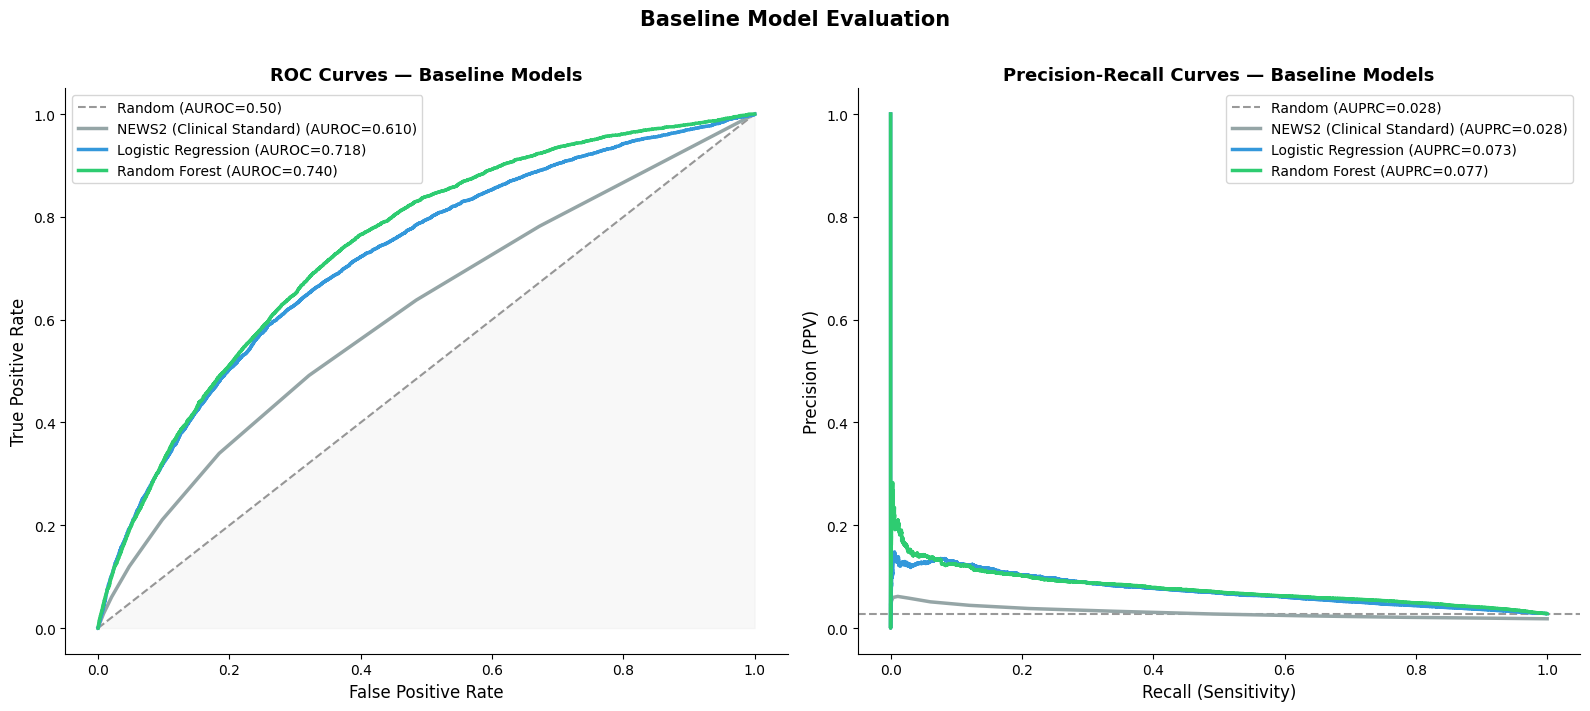

Saved to research/notes/baseline_roc_prc.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- ROC Curves ---
ax = axes[0]
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random (AUROC=0.50)')

for name, r in results.items():
    try:
        if name == 'NEWS2 (Clinical Standard)':
            fpr, tpr, _ = roc_curve(df_raw['SepsisLabel'], df_raw['news2_prob'])
        else:
            fpr, tpr, _ = roc_curve(y_test, r['probs'])
        ax.plot(fpr, tpr, color=r['color'], linewidth=2.5,
                label=f"{name} (AUROC={r['auroc']:.3f})")
    except:
        pass

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Baseline Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')

# --- Precision-Recall Curves ---
ax = axes[1]
baseline_rate = y_test.mean()
ax.axhline(y=baseline_rate, color='k', linestyle='--', alpha=0.4,
           label=f'Random (AUPRC={baseline_rate:.3f})')

for name, r in results.items():
    try:
        if name == 'NEWS2 (Clinical Standard)':
            prec, rec, _ = precision_recall_curve(df_raw['SepsisLabel'], df_raw['news2_prob'])
        else:
            prec, rec, _ = precision_recall_curve(y_test, r['probs'])
        ax.plot(rec, prec, color=r['color'], linewidth=2.5,
                label=f"{name} (AUPRC={r['auprc']:.3f})")
    except:
        pass

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title('Precision-Recall Curves — Baseline Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('Baseline Model Evaluation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'baseline_roc_prc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to research/notes/baseline_roc_prc.png')

## 7. Where Do Baselines Fail?

Optimal threshold (max F1 on val): 0.580


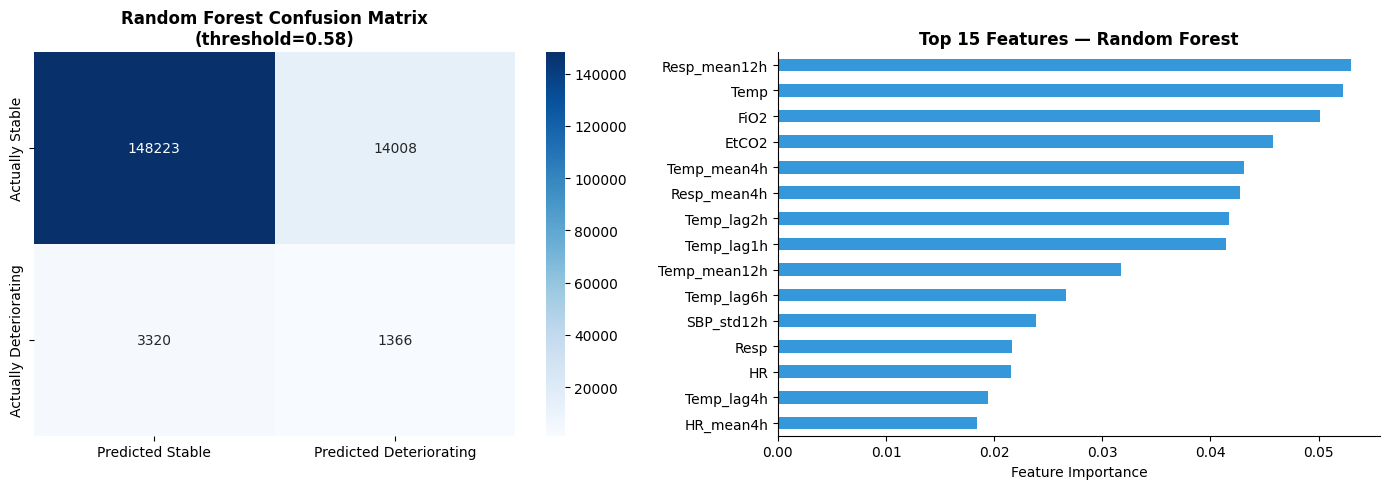


=== CLINICAL METRICS AT OPTIMAL THRESHOLD ===
Sensitivity (Recall):  0.292  — % of true deteriorations caught
Specificity:           0.914  — % of stable patients correctly identified
Precision (PPV):       0.089  — % of alerts that are real
False Negatives:       3,320    — deteriorations MISSED ← most dangerous
False Positives:       14,008    — false alarms ← causes alert fatigue


In [8]:
# Confusion matrix at optimal threshold for Random Forest
# Optimal threshold = maximizes F1 score on validation set
prec_val, rec_val, thresholds_val = precision_recall_curve(y_val, rf_probs_val)
f1_scores = 2 * prec_val * rec_val / (prec_val + rec_val + 1e-8)
optimal_threshold = thresholds_val[np.argmax(f1_scores[:-1])]

print(f'Optimal threshold (max F1 on val): {optimal_threshold:.3f}')

rf_preds = (rf_probs_test >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, rf_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Stable', 'Predicted Deteriorating'],
            yticklabels=['Actually Stable', 'Actually Deteriorating'])
axes[0].set_title(f'Random Forest Confusion Matrix\n(threshold={optimal_threshold:.2f})',
                  fontweight='bold')

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

# Feature importance
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=False).head(15)
feat_imp.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Top 15 Features — Random Forest', fontweight='bold')
axes[1].set_xlabel('Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'baseline_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== CLINICAL METRICS AT OPTIMAL THRESHOLD ===')
print(f'Sensitivity (Recall):  {sensitivity:.3f}  — % of true deteriorations caught')
print(f'Specificity:           {specificity:.3f}  — % of stable patients correctly identified')
print(f'Precision (PPV):       {ppv:.3f}  — % of alerts that are real')
print(f'False Negatives:       {fn:,}    — deteriorations MISSED ← most dangerous')
print(f'False Positives:       {fp:,}    — false alarms ← causes alert fatigue')

## 8. Calibration Analysis

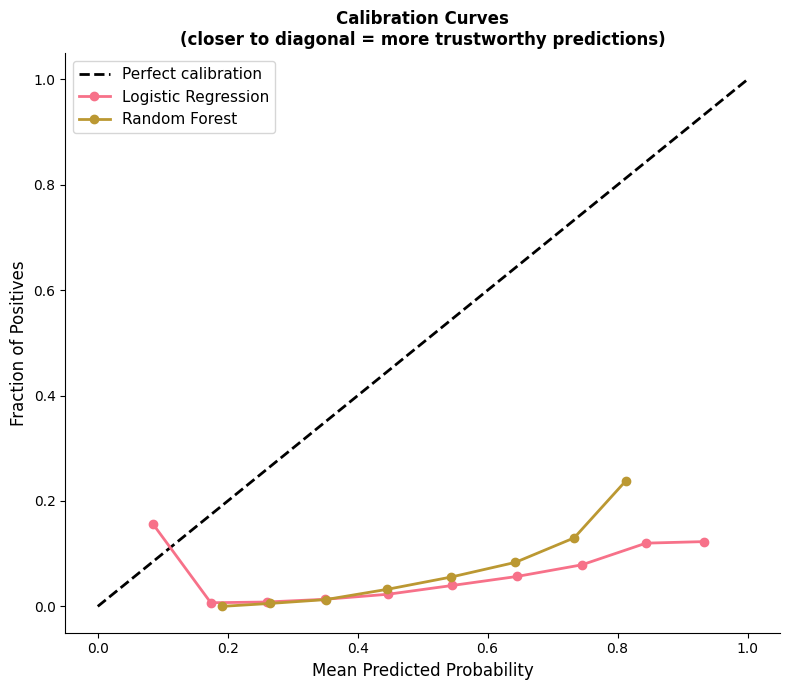


Note: Poor calibration is why doctors distrust black-box models.
Our LSTM will include calibration as a key evaluation metric.


In [9]:
# Calibration: are predicted probabilities trustworthy?
# A well-calibrated model: P=0.8 means 80% of those patients actually deteriorate

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0,1],[0,1],'k--', label='Perfect calibration', linewidth=2)

for name, r in [('Logistic Regression', lr_probs_test), ('Random Forest', rf_probs_test)]:
    try:
        prob_true, prob_pred = calibration_curve(y_test, r, n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=name)
    except:
        pass

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves\n(closer to diagonal = more trustworthy predictions)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'baseline_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNote: Poor calibration is why doctors distrust black-box models.')
print('Our LSTM will include calibration as a key evaluation metric.')

## 9. Save Baseline Results

In [10]:
baseline_results = {
    'news2': {
        'auroc': round(news2_auroc, 4),
        'auprc': round(news2_auprc, 4),
    },
    'logistic_regression': {
        'auroc': round(lr_auroc, 4),
        'auprc': round(lr_auprc, 4),
    },
    'random_forest': {
        'auroc': round(rf_auroc, 4),
        'auprc': round(rf_auprc, 4),
        'optimal_threshold': round(float(optimal_threshold), 4),
        'sensitivity': round(float(sensitivity), 4),
        'specificity': round(float(specificity), 4),
        'ppv': round(float(ppv), 4),
    },
    'target_for_lstm': {
        'auroc': f'> {max(news2_auroc, lr_auroc, rf_auroc):.4f}',
        'note': 'LSTM must beat best baseline on both AUROC and AUPRC'
    }
}

with open(DATA_DIR / 'baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print('Baseline results saved to data/processed/baseline_results.json')

Baseline results saved to data/processed/baseline_results.json


## 10. Baseline Summary

In [11]:
best_auroc = max(news2_auroc, lr_auroc, rf_auroc)
best_auprc = max(news2_auprc, lr_auprc, rf_auprc)

print('=' * 58)
print('     ICU-WATCH — BASELINE RESULTS SUMMARY')
print('=' * 58)
print(f'''
📊 RESULTS
   {'Model':<30} {'AUROC':>8} {'AUPRC':>8}
   {'-'*48}
   {'NEWS2 (Clinical Standard)':<30} {news2_auroc:>8.4f} {news2_auprc:>8.4f}
   {'Logistic Regression':<30} {lr_auroc:>8.4f} {lr_auprc:>8.4f}
   {'Random Forest':<30} {rf_auroc:>8.4f} {rf_auprc:>8.4f}
   {'-'*48}
   {'LSTM Target':<30} {">"+str(round(best_auroc,4)):>8} {">"+str(round(best_auprc,4)):>8}

🎯 KEY INSIGHT
   Baselines only see the CURRENT hour snapshot.
   Our LSTM sees 12 HOURS of temporal context.
   That temporal awareness is our competitive edge.

⚠️ WHERE BASELINES FAIL
   High false negatives — they miss subtle early deterioration
   Poor calibration — predicted probabilities not trustworthy
   No temporal context — they ignore the trajectory

🚀 NEXT STEP
   notebooks/04_deep_model.ipynb
   Train LSTM with 12h temporal context + attention
   Target: beat all baselines on AUROC and AUPRC
''')
print('=' * 58)

     ICU-WATCH — BASELINE RESULTS SUMMARY

📊 RESULTS
   Model                             AUROC    AUPRC
   ------------------------------------------------
   NEWS2 (Clinical Standard)        0.6095   0.0281
   Logistic Regression              0.7179   0.0732
   Random Forest                    0.7402   0.0772
   ------------------------------------------------
   LSTM Target                     >0.7402  >0.0772

🎯 KEY INSIGHT
   Baselines only see the CURRENT hour snapshot.
   Our LSTM sees 12 HOURS of temporal context.
   That temporal awareness is our competitive edge.

⚠️ WHERE BASELINES FAIL
   High false negatives — they miss subtle early deterioration
   Poor calibration — predicted probabilities not trustworthy
   No temporal context — they ignore the trajectory

🚀 NEXT STEP
   notebooks/04_deep_model.ipynb
   Train LSTM with 12h temporal context + attention
   Target: beat all baselines on AUROC and AUPRC

